# Physical investigation of the "perceptual" colour space

In [1]:
# # Silent installation or update
#
# # Clean cache
# !python3 -m pip cache purge -q
#
# # Force updating
# package_update = [
#     "pip",
#     "scikit-learn",
#     "pandas",
# ]
#
# for package_name in package_update:
#     !bash -c "python3 -m pip install -U '{package_name}' -q"
#
# # Install missing packages
# package_array = [
#     "jinja2",
#     "ipywidgets",
#     "nbformat",
#     "numpy",
#     "matplotlib",
#     "opencv-python",
#     "colour-science",
# ]
#
# for package_name in package_array:
#     !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


## Target radiation

Source: [PhD dissertation](https://rada.kpi.ua/files/dissertation/dis_Pinchuk%20B.Yu.pdf)

The spectral radiant emittance of a blackbody is determined by the Planck function:
$$
 M \left ( \lambda , T \right ) = \frac{c_{1}}{\lambda ^{5}\cdot \left [ exp\left ( \frac{c_{2}}{\lambda \cdot T} \right ) - 1 \right ]}
\left [ \frac{W}{cm^{2} \cdot \mu m} \right ]
$$
where:
$c_{1}$ - 37415 $W \cdot cm^{-2} \cdot \mu m^{4}$, $c_{2}$ - 14388 $\mu m \cdot K$, $\lambda$ - wavelength in $\mu m$.

Sources:
* [Абсолютно чорне тіло](https://uk.wikipedia.org/wiki/Абсолютно_чорне_тіло)
* [Wien's displacement law](https://en.wikipedia.org/wiki/Wien%27s_displacement_law)

Peaks at the wavelength:
$$
\lambda _{peak} = \frac{b}{T} \left [ \mu m \right ]
$$
where: $b$ = 2897.77 $\mu m \cdot K$ - is Wien's displacement constant.

Sources:
* [Видиме світло](https://uk.wikipedia.org/wiki/Видиме_світло)
* [Visible spectrum](https://en.wikipedia.org/wiki/Visible_spectrum)

Spectral colors:
Color | Wavelength (nm)
---|---
🟦 blue | 450–485
🟩 green | 500–565
🟥 red | 625–750

In [2]:
import apps.reporter as rpt

b = 2897.77

rp = rpt.Reporter()
rp.tolerance = 3

# average wavelength of the colors in micrometers
lambda_b = ((450 + 485) / 2) / 1000.0
lambda_g = ((500 + 565) / 2) / 1000.0
lambda_r = ((625 + 750) / 2) / 1000.0

rp.add_item("🟦 blue: λ", f"{rp.format_value(lambda_b)} μm")
rp.add_item("🟩 green: λ", f"{rp.format_value(lambda_g)} μm")
rp.add_item("🟥 red: λ", f"{rp.format_value(lambda_r)} μm")

# temperatures of these colors in Kelvins
T_b = b / lambda_b
T_g = b / lambda_g
T_r = b / lambda_r

rp.add_item("🟦 blue: T", f"{rp.format_value(T_b)} ºK")
rp.add_item("🟩 green: T", f"{rp.format_value(T_g)} ºK")
rp.add_item("🟥 red: T", f"{rp.format_value(T_r)} ºK")

# Print results
rp.print_pd_report("Color wavelength and temperature")

Attribute,Result
🟦 blue: λ,0.468 μm
🟩 green: λ,0.532 μm
🟥 red: λ,0.688 μm
🟦 blue: T,6198.439 ºK
🟩 green: T,5441.822 ºK
🟥 red: T,4214.938 ºK


In [3]:
import numpy as np


def planck_law(wavelength: np.ndarray | float, temperature: np.ndarray | float) -> np.ndarray | float:
    """
    Calculation spectral radiant emittance
    :param wavelength: wavelength in micrometers
    :param temperature: temperature in Kelvins
    :return: spectral radiant emittance
    """
    c_1 = 37415.0
    c_2 = 14388.0
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        sre = c_1 / ((wavelength ** 5.0) * (np.exp(c_2 / (wavelength * temperature)) - 1.0))

    sre = np.nan_to_num(sre, nan=0.0, posinf=0.0)

    if isinstance(sre, np.ndarray) and sre.ndim == 0:
        return float(sre)

    return sre


In [4]:
import numpy as np

n_points = 1000
lambda_min = 0.0
lambda_max = 3.0
# lambda_min = 0.35
# lambda_max = 0.83

wavelengths_mkm = np.linspace(lambda_min, lambda_max, n_points)

# calculate data for charts
M_b = planck_law(wavelengths_mkm, T_b)
M_g = planck_law(wavelengths_mkm, T_g)
M_r = planck_law(wavelengths_mkm, T_r)


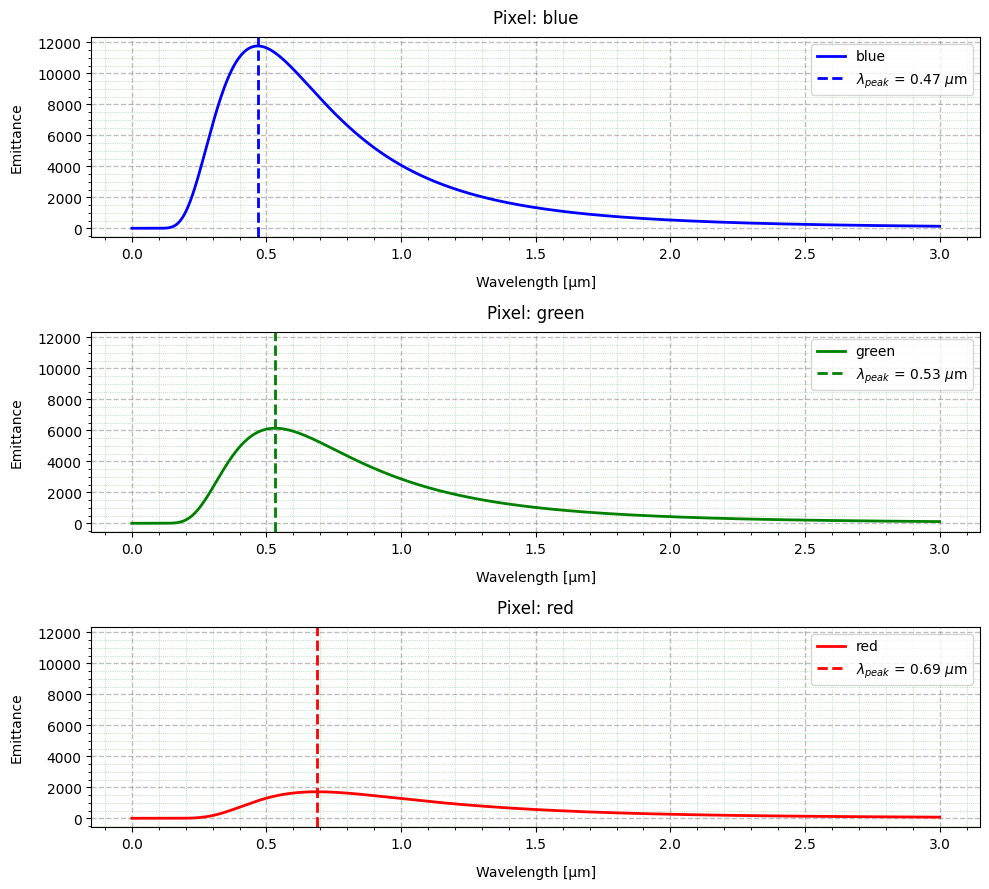

In [5]:
import matplotlib.pyplot as plt

M_array = [M_b, M_g, M_r]
lambda_peaks = [lambda_b, lambda_g, lambda_r]
colors = ["blue", "green", "red"]

_, axes = plt.subplots(len(M_array), 1, figsize=(10, 9), sharey=True)

for idx, item in enumerate(M_array):
    ax = axes[idx]

    ax.plot(wavelengths_mkm, M_array[idx], linewidth=2.0, color=colors[idx], label=colors[idx])
    ax.axvline(lambda_peaks[idx], linestyle='--', color=colors[idx], linewidth=2.0,
               label=f"$\\lambda _{{peak}}$ = {lambda_peaks[idx]:.2f} $\\mu$m")

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Pixel: {colors[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Emittance", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

## Eye sensitivity

Sources:
* [Colour Matching Functions Spectral Power Distributions](https://www.colour-science.org/api/0.3.4/html/colour.colorimetry.dataset.cmfs.html)
* [CVRL Database](http://www.cvrl.org/ciexyzpr.htm)



In [16]:
import colour

use_2_degrees = True

colour_dataset_name = ("Stockman & Sharpe 2 Degree Cone Fundamentals"
                       if use_2_degrees
                       else "Stockman & Sharpe 10 Degree Cone Fundamentals")

cone_fundamentals = colour.MSDS_CMFS[colour_dataset_name].copy()
wavelengths_nm = wavelengths_mkm * 1000.0

L_signal = cone_fundamentals.signals["l_bar"]
M_signal = cone_fundamentals.signals["m_bar"]
S_signal = cone_fundamentals.signals["s_bar"]

L_bar = L_signal.extrapolator(
    L_signal.interpolator(L_signal.wavelengths, L_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm)

M_bar = M_signal.extrapolator(
    M_signal.interpolator(M_signal.wavelengths, M_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm)

S_bar = S_signal.extrapolator(
    S_signal.interpolator(S_signal.wavelengths, S_signal.values),
    method="Constant", left=0, right=0)(wavelengths_nm)


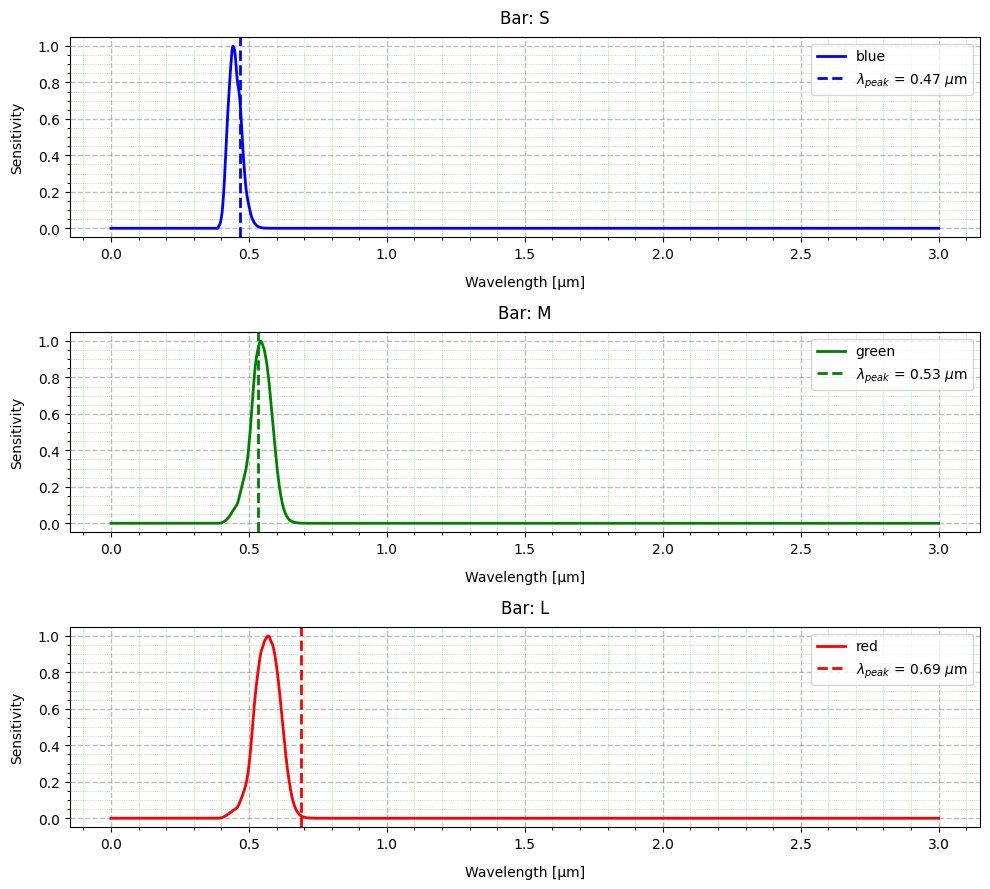

In [17]:
import matplotlib.pyplot as plt

L_array = [S_bar, M_bar, L_bar]
lambda_peaks = [lambda_b, lambda_g, lambda_r]
bars = ['S', 'M', 'L']

_, axes = plt.subplots(len(M_array), 1, figsize=(10, 9), sharey=True)

for idx, item in enumerate(L_array):
    ax = axes[idx]

    ax.plot(wavelengths_mkm, L_array[idx], linewidth=2.0, color=colors[idx], label=colors[idx])
    ax.axvline(lambda_peaks[idx], linestyle='--', color=colors[idx], linewidth=2.0,
               label=f"$\\lambda _{{peak}}$ = {lambda_peaks[idx]:.2f} $\\mu$m")

    ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
    ax.minorticks_on()
    ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
    ax.set_title(f"Bar: {bars[idx]}", pad=10, loc='center', color='black')
    ax.set_xlabel("Wavelength [μm]", labelpad=10, loc='center', color='black')
    ax.set_ylabel("Sensitivity", labelpad=10, loc='center', color='black')
    ax.legend()

plt.tight_layout()
plt.show()

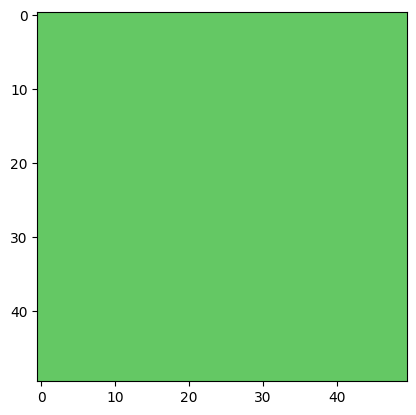

In [7]:
import numpy as np
import matplotlib.pyplot as plt

color_1 = np.zeros((50, 50, 3), dtype=np.uint8)
color_1[..., 0], color_1[..., 1], color_1[..., 2] = 100, 200, 100

# color_1[..., 0] = 100
# color_1[..., 1] = 200
# color_1[..., 2] = 100

plt.imshow(color_1)
# plt.show()
# color_2 = np.zeros((50, 50, 3), dtype=np.uint8)